# ✈️ Flykite Airlines — HR Policy Q&A Bot

**An end-to-end retrieval-augmented generation system for accurate, evidence-linked employee guidance.**

---

## Business Context
Internal HR policies covering leave, benefits, probation, conduct, and compliance are documented in a long, static handbook. Employees may struggle to locate and interpret the relevant clauses, creating repetitive queries for HR and delays for employees.

## System Objectives
- **Retrieve official policy evidence** before answering company-specific questions.
- **Handle ambiguity and follow-ups** through a clarification check and optional conversation history.
- **Accept role, location, and department context** without inventing profile-specific differences that the handbook does not contain.
- **Increase trust through traceable evidence** by identifying the document, page, section, and retrieved clause used for each policy answer.

## Benchmark Questions
1. *What are the effects on the benefits I receive if my probation is extended?*
2. *There has been a demise in my family last night, and I need to attend the last rites. How should I inform the office, and will I be granted leave?*
3. *What should I do if I notice suspected harassment with my female colleague?*

## Notebook Roadmap
| # | Section | Purpose |
|---|---------|---------|
| 1 | Question Answering using **LLM only** | Establish a no-retrieval baseline |
| 2 | Question Answering using **LLM + Prompt Engineering** | Test safer prompting without policy access |
| 3 | **Data Preparation for RAG** | Clean, split, embed, index, and validate retrieval |
| 4 | Question Answering using **RAG** | Generate evidence-linked policy answers |
| 5 | **RAG Fine-Tuning** | Compare six retrieval configurations |
| 6 | **Actionable Insights & Recommendations** | Interpret results for business use |
| 7 | **System Behaviour Demonstration** | Test ambiguity, follow-up context, and employee profile handling |
| 8 | **Conclusion** | Summarise findings, limitations, and operational safeguards |

**Runtime:** Google Colab → GPU (T4). **Decoding:** greedy (`temperature = 0.0`), seed 42.

## 0. Environment Setup

Libraries used across the pipeline:
- **LangChain** (orchestration) with **transformers / accelerate / bitsandbytes** for the 4-bit quantized open LLM on the T4 GPU,
- **sentence-transformers** and **FAISS** for embeddings and vector search,
- **pypdf** for PDF loading, **pandas / matplotlib** for evaluation and charts.

The install cell runs once per session; the session was restarted at Colab's prompt and execution resumed from the imports cell.

In [1]:
%%capture
# --- Install dependencies (Colab / T4-GPU) ---
# Qwen3 (LLM + the Qwen3 embedding model used in fine-tuning) needs a recent
# transformers, so `-U` pulls the latest wheel that ships the qwen3 architecture.
%pip install -q -U \
    "langchain>=0.3" "langchain-community>=0.3" "langchain-core>=0.3" \
    "langchain-huggingface>=0.1" "langchain-text-splitters>=0.3" \
    "transformers>=4.51" "accelerate>=0.34" "bitsandbytes>=0.43" \
    "sentence-transformers>=3.0" "faiss-cpu>=1.8" "pypdf>=4.0" \
    pandas matplotlib

In [2]:
# --- Imports ---
import os, re, time, json, logging, warnings, textwrap, unicodedata
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

# Keep the notebook output clean: silence non-critical logs and download bars
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import transformers
transformers.logging.set_verbosity_error()
try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
except Exception:
    pass
# These loggers are separate from transformers' logging, so quiet them explicitly.
for _noisy in ("huggingface_hub", "sentence_transformers", "datasets"):
    logging.getLogger(_noisy).setLevel(logging.ERROR)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU check
print("PyTorch:", torch.__version__)
if torch.cuda.is_available():
    print("✅ GPU:", torch.cuda.get_device_name(0))
    print("   VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("⚠️ No GPU detected. Set Runtime → Change runtime type → GPU (T4).")

# --- Optional Hugging Face Hub authentication ---
# A token raises rate limits and makes downloads faster. The models used here are
# ungated, so authentication is optional. The token is read from the environment or
# Colab Secrets and is never hardcoded; keep credentials out of notebooks and version control.
if not os.environ.get("HF_TOKEN"):
    try:
        from google.colab import userdata  # add HF_TOKEN under the 🔑 "Secrets" panel
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    except Exception:
        pass  # no secret or not on Colab; ungated models still work
print("HF Hub:", "✅ authenticated" if os.environ.get("HF_TOKEN")
      else "ℹ️ unauthenticated (ungated models still download, just rate-limited)")

PyTorch: 2.11.0+cu128
✅ GPU: Tesla T4
   VRAM: 15.6 GB
HF Hub: ℹ️ unauthenticated (ungated models still download, just rate-limited)


### 0.1 Configuration

Central place for the model IDs, file paths, the three benchmark questions, and default generation/RAG parameters.

- **LLM:** `Qwen/Qwen3-4B-Instruct-2507` — a compact, modern open instruct model (**Apache-2.0, ungated — no access token needed**). It runs in **non-thinking mode only** (no hidden `<think>` traces), supports a native *system* role, and at 4B it loads fast and light on a T4 in **4-bit** quantization (~8 GB download vs ~15 GB for a 7B) — well-suited to this 14-page handbook. A larger drop-in alternative is `Qwen/Qwen3-8B` (ungated; enable thinking off).
- **Embeddings:** `sentence-transformers/all-MiniLM-L6-v2` (fast, 384-dim) as the default. A stronger, state-of-the-art alternative, `Qwen/Qwen3-Embedding-0.6B` (1024-dim, top of the MTEB leaderboard), is tried during fine-tuning.

In [3]:
# --- Configuration ---
LLM_MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"  # compact, ungated, non-thinking (Apache-2.0)
EMB_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
PDF_PATH = "/content/drive/MyDrive/Dataset-FlykiteAirlines_HRP.pdf"

# Default generation parameters.
# temperature=0.0 gives deterministic greedy decoding, appropriate for factual policy guidance.
GEN_PARAMS = dict(max_new_tokens=512, temperature=0.0, top_p=0.9, repetition_penalty=1.1)

# Default RAG parameters
RAG_DEFAULTS = dict(chunk_size=800, chunk_overlap=150, k=4, search_type="similarity")

# The three benchmark questions used in this evaluation
QUESTIONS = [
    "What are the effects on the benefits I receive if my probation is extended?",
    "There has been a demise in my family last night, and I need to attend the last rites. "
    "How should I inform the office, and will I be granted leave?",
    "What should I do if I notice suspected harassment with my female colleague?",
]

# Short labels for tables and plots
Q_LABELS = ["Q1: Probation extension", "Q2: Bereavement leave", "Q3: Harassment reporting"]

# Handbook-sourced key facts used for a transparent fact-coverage diagnostic.
EXPECTED_FACTS = {
    0: ["performance bonus", "annual leave encashment", "internal role transfer",
        "not eligible", "seniority"],
    1: ["special leave", "bereavement", "5", "working days", "immediate family"],
    2: ["report", "15 calendar days", "hr helpline", "hr.ethics", "anonymous", "retaliation"],
}

print("Configuration loaded.")
for lbl, q in zip(Q_LABELS, QUESTIONS):
    print(f"  • {lbl}: {q[:70]}...")

Configuration loaded.
  • Q1: Probation extension: What are the effects on the benefits I receive if my probation is exte...
  • Q2: Bereavement leave: There has been a demise in my family last night, and I need to attend ...
  • Q3: Harassment reporting: What should I do if I notice suspected harassment with my female colle...


### 0.2 Load the HR Handbook

The knowledge source is **`Dataset-FlykiteAirlines_HRP.pdf`**, stored in Google Drive at the path set by `PDF_PATH` in the configuration cell. The cell below mounts Drive (on Colab), reads that file directly, and prints a quick profile (page count, characters) to confirm it loaded correctly.

In [4]:
# --- Load the HR handbook PDF (from Google Drive) ---
# PDF_PATH is set in the configuration cell. On Colab we mount Drive so that path is
# accessible, then read the file directly — no copying, uploading, or searching.
if PDF_PATH.startswith("/content/drive") and not os.path.ismount("/content/drive"):
    from google.colab import drive
    drive.mount("/content/drive")

if not os.path.exists(PDF_PATH):
    raise FileNotFoundError(
        f"Handbook PDF not found at '{PDF_PATH}'. "
        "Update PDF_PATH in the configuration cell to point to the file in your Drive."
    )

# Quick profile with pypdf
from pypdf import PdfReader
_reader = PdfReader(PDF_PATH)
_raw = "".join((p.extract_text() or "") for p in _reader.pages)
print(f"✅ Loaded '{PDF_PATH}'")
print(f"   Pages: {len(_reader.pages)} | Characters: {len(_raw):,}")
print("\n--- First 600 characters (raw extract) ---\n")
print(re.sub(r"\s+", " ", _raw)[:600])

Mounted at /content/drive
✅ Loaded '/content/drive/MyDrive/Dataset-FlykiteAirlines_HRP.pdf'
   Pages: 14 | Characters: 18,214

--- First 600 characters (raw extract) ---

 Flykite Airlines: Human Resources Policy Handbook Introduction Flykite Airlines is dedicated to cultivating an organizational culture that synergizes operational excellence with a supportive, equitable, and legally compliant workplace environment across all departments and employee levels. This document establishes an exhaustive framework comprising all human resource policies currently in effect. All provisions are subject to amendment, interpretation, or rescindment at the sole discretion of the Human Resources and Legal departments. In the event of ambiguities or conﬂicting interpretations


### 0.3 Evaluation Methodology — Groundedness & Relevance

Every method is evaluated on the same basis so results remain comparable. Three lightweight, deterministic metrics are used without an external judge API:

| Metric | What it measures | How it is computed |
|--------|------------------|--------------------|
| **Relevance** | Does the answer address the question? | Cosine similarity between embeddings of the answer and question |
| **Groundedness proxy** | Is the answer semantically aligned with handbook evidence? | Mean of the top-3 cosine similarities between the answer and its most similar handbook passages |
| **Fact coverage** | Did it state the key policy facts? | Fraction of pre-listed handbook-sourced facts present in the answer |

All scores are in **0–1** (higher is better). The same `all-MiniLM-L6-v2` evaluator is used for every method, and every answer is retained for qualitative review.

> **Interpretation boundary:** embedding similarity is a reproducible groundedness *proxy*, not claim-level proof. RAG answers therefore receive a separate citation-completeness audit, followed by inspection of the displayed document, section, page, and retrieved clause. Quantitative scores and qualitative review are interpreted together.

In [5]:
# --- Evaluation utilities (embedding-based, deterministic) ---
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("Loading embedding model for evaluation...")
eval_embeddings = HuggingFaceEmbeddings(
    model_name=EMB_MODEL_ID,
    model_kwargs={"device": "cuda" if torch.cuda.is_available() else "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

def _clean_text(text: str) -> str:
    """Strip the repeating per-page watermark/footer from the *extracted text*
    (the PDF file itself is never modified) so the boilerplate isn't embedded
    into the retrieval chunks or fed to the model. Genuine handbook content —
    including the HR `@flykiteair.com` contact email — is preserved.
    """
    # Normalise unicode ligatures (e.g. 'ﬂ'->'fl') and the PDF's irregular spacing
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\s+", " ", text)
    # 1) The per-page "personal use" watermark line (incl. its embedded personal email)
    text = re.sub(r"This file is meant for personal use by .*? only\.?", " ", text,
                  flags=re.IGNORECASE)
    # 2) The repeated legal footer and standalone 10-character order/watermark code
    text = re.sub(
        r"Sharing or publishing the contents in part or full is liable for legal action\.?",
        " ", text, flags=re.IGNORECASE,
    )
    text = re.sub(r"\b[A-Z0-9]{10}\b", " ", text)
    # 3) Any remaining non-company email; @flykiteair.com addresses are preserved
    text = re.sub(r"[\w.+-]+@(?!flykiteair\.com\b)[\w-]+\.[\w.-]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

# Reference corpus for groundedness scoring — handbook text with the watermark removed
_ref_text = _clean_text(_raw)
_ref_passages = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80).split_text(_ref_text)
_ref_matrix = np.array(eval_embeddings.embed_documents(_ref_passages))  # (N, dim), normalised
print(f"Reference corpus: {len(_ref_passages)} passages embedded for groundedness scoring.")

def _embed(text: str) -> np.ndarray:
    return np.array(eval_embeddings.embed_query(text or ""))

# Strip source footers and inline page tags so every method is scored on answer text only.
def _strip_citation(a: str) -> str:
    a = re.sub(r"\n*📄 Source(?:s)?:.*$", "", a or "", flags=re.S).strip()
    return re.sub(r"\[Page\s+\d+\]", "", a, flags=re.IGNORECASE).strip()

def relevance_score(answer: str, question: str) -> float:
    return float(np.dot(_embed(answer), _embed(question)))

def groundedness_score(answer: str, top_n: int = 3) -> float:
    """Mean of the top-N cosine similarities between the answer and handbook passages."""
    sims = _ref_matrix @ _embed(answer)
    return float(np.sort(sims)[-top_n:].mean())

def _fact_present(fact: str, text: str) -> bool:
    """Whole-word / whole-phrase match (case-insensitive, flexible whitespace).
    Using word boundaries means the fact "5" matches "5 working days" but NOT
    "2507" or "15", and "report" won't match unrelated substrings — making the
    fact-coverage metric trustworthy rather than inflated by incidental matches."""
    pattern = r"\b" + r"\s+".join(re.escape(w) for w in fact.split()) + r"\b"
    return re.search(pattern, text, flags=re.IGNORECASE) is not None

def fact_coverage(answer: str, q_index: int) -> float:
    facts = EXPECTED_FACTS.get(q_index, [])
    if not facts:
        return float("nan")
    a = _strip_citation(answer)
    return round(sum(_fact_present(f, a) for f in facts) / len(facts), 3)

def evaluate_answers(answers, method_name):
    """answers: list[str] aligned with QUESTIONS. Returns a tidy DataFrame of scores.
    Citations are stripped before scoring so all methods are judged on answer text only."""
    rows = []
    for i, (q, a) in enumerate(zip(QUESTIONS, answers)):
        a_clean = _strip_citation(a)
        rows.append({
            "method": method_name,
            "question": Q_LABELS[i],
            "relevance": round(relevance_score(a_clean, q), 3),
            "groundedness": round(groundedness_score(a_clean), 3),
            "fact_coverage": fact_coverage(a_clean, i),
        })
    return pd.DataFrame(rows)

def show_answers(answers, title):
    print(f"\n{'='*90}\n{title}\n{'='*90}")
    for lbl, a in zip(Q_LABELS, answers):
        print(f"\n### {lbl}\n")
        print(textwrap.fill(a, width=100))
        print("-" * 90)

print("Evaluation utilities ready: relevance_score, groundedness_score, fact_coverage, evaluate_answers.")

Loading embedding model for evaluation...
Reference corpus: 31 passages embedded for groundedness scoring.
Evaluation utilities ready: relevance_score, groundedness_score, fact_coverage, evaluate_answers.


---
## 1. Question Answering using the LLM (baseline, no retrieval)

**Goal:** establish a baseline by asking the raw LLM the three questions with a simple, generic prompt and **no access to the handbook**. This tests whether a general-purpose model can reliably answer questions about Flykite-specific policy without supporting evidence.

Implementation steps:
1. **Load the LLM** — `Qwen3-4B-Instruct-2507` in 4-bit on the T4 GPU.
2. **Create a response-generation function** exposing the model parameters.
3. **Apply it** to the three benchmark questions.
4. **Evaluate** groundedness, relevance, and fact coverage, then review the answers qualitatively.

In [6]:
# --- Load the LLM in 4-bit on the GPU and wrap it for LangChain ---
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading {LLM_MODEL_ID} (4-bit)... this can take a few minutes on first run.")
# clean_up_tokenization_spaces=False is the correct setting for BPE tokenizers (Qwen),
# and silences the "Ignoring clean_up_tokenization_spaces" warning at the source.
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID, clean_up_tokenization_spaces=False)
model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
)

# Generation length is governed solely by max_new_tokens. Clearing the default
# max_length (=20) prevents the "Both max_new_tokens and max_length set" warning,
# and pinning pad_token_id avoids the pad-token notice during generation.
model.generation_config.max_length = None
model.generation_config.pad_token_id = tokenizer.eos_token_id

# Some chat templates (e.g. Gemma) don't accept a separate "system" role. Detect
# this once so our prompt helpers stay model-agnostic (Qwen, Gemma, Zephyr, ...).
def _supports_system_role(tok) -> bool:
    try:
        tok.apply_chat_template(
            [{"role": "system", "content": "x"}, {"role": "user", "content": "y"}],
            tokenize=False, add_generation_prompt=True,
        )
        return True
    except Exception:
        return False

SUPPORTS_SYSTEM_ROLE = _supports_system_role(tokenizer)
print(f"   chat template supports a system role: {SUPPORTS_SYSTEM_ROLE}")

def build_messages(system_prompt: str, user_prompt: str):
    """Return chat messages that work whether or not the model's chat template
    accepts a separate system role. If it doesn't (e.g. Gemma), the system
    instructions are folded into the user turn."""
    if SUPPORTS_SYSTEM_ROLE:
        return [SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)]
    return [HumanMessage(content=f"{system_prompt}\n\n{user_prompt}")]

def make_llm(temperature=GEN_PARAMS["temperature"],
             max_new_tokens=GEN_PARAMS["max_new_tokens"],
             top_p=GEN_PARAMS["top_p"],
             repetition_penalty=GEN_PARAMS["repetition_penalty"]):
    """Build a LangChain chat LLM with configurable generation parameters."""
    text_pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=max_new_tokens,
        do_sample=temperature > 0,
        temperature=max(temperature, 1e-3),
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        return_full_text=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    return ChatHuggingFace(llm=HuggingFacePipeline(pipeline=text_pipe), tokenizer=tokenizer)

llm = make_llm()
print("✅ LLM ready.")

Loading Qwen/Qwen3-4B-Instruct-2507 (4-bit)... this can take a few minutes on first run.
   chat template supports a system role: True
✅ LLM ready.


In [7]:
# --- Response generation function (baseline) ---
BASELINE_SYSTEM = "You are a helpful HR assistant. Answer the employee's question."

def generate_response(question: str, system_prompt: str = BASELINE_SYSTEM, chat_model=None) -> str:
    """Generate an answer for a single question using the given system prompt."""
    chat_model = chat_model or llm
    messages = build_messages(system_prompt, question)
    return chat_model.invoke(messages).content.strip()

# Apply to the three benchmark questions
print("Generating baseline (LLM-only) answers...\n")
baseline_answers = [generate_response(q) for q in QUESTIONS]
show_answers(baseline_answers, "1. LLM-ONLY (BASELINE) ANSWERS")

Generating baseline (LLM-only) answers...


1. LLM-ONLY (BASELINE) ANSWERS

### Q1: Probation extension

Great question — as an HR assistant, I can help clarify how extending your probationary period might
affect your benefits.  In most cases, **extending your probationary period does not automatically
change or reduce your benefits**, especially if you're still employed and in good standing. Here’s
what typically happens:  ### 1. **Benefits Are Usually Maintained** - Your health insurance,
retirement contributions (like 401(k)), paid time off (PTO), and other standard benefits generally
continue during an extended probation. - Employers usually do not withhold benefits simply because
someone is on probation or has their probation extended — these benefits are tied to employment
status, not probation duration.  ### 2. **Probation Extension ≠ Termination or Reduced Pay** - An
extension of probation means you’re being given more time to meet performance goals or complete
training, not th

In [8]:
# --- Evaluate baseline (groundedness & relevance) ---
baseline_eval = evaluate_answers(baseline_answers, "1. LLM-only")
display(baseline_eval)
print("\nMethod averages:")
display(baseline_eval[["relevance", "groundedness", "fact_coverage"]].mean().round(3).to_frame("mean"))

,method,question,relevance,groundedness,fact_coverage
0,1. LLM-only,Q1: Probation extension,0.806,0.590,0.000
1,1. LLM-only,Q2: Bereavement leave,0.665,0.424,0.400
2,1. LLM-only,Q3: Harassment reporting,0.823,0.453,0.333



Method averages:


,mean
relevance,0.765
groundedness,0.489
fact_coverage,0.244


#### 🗒️ Observations — LLM-only (baseline)

- **Relevance is high** — the model understands the topics and writes fluent, on-topic general HR advice.
- **Groundedness and fact coverage are limited** — the model has no access to Flykite's handbook, so it substitutes company-agnostic assumptions about benefits, bereavement, and reporting processes. It cannot reliably state Flykite-specific restrictions, deadlines, approval conditions, or reporting channels.
- **No citations** — answers cannot point to policy evidence, so they are not trustworthy for compliance.
- **Risk:** confidently stated but unsupported specifics are worse than an explicit "I cannot verify that" in an HR context.

**Takeaway:** A raw LLM is a fluent generalist but an unreliable source of this company's policy. This motivates a stricter no-retrieval prompt and, more importantly, grounding via RAG.

---
## 2. Question Answering using the LLM + Prompt Engineering

**Goal:** improve answer quality **without** retrieval, purely by engineering the prompt. We still don't give the model the handbook, so it *still* can't be truly grounded — but good prompting makes it **safer** (admit uncertainty, avoid inventing numbers) and **better structured**.

Prompt-engineering techniques applied:
- **Role & domain framing** — "expert HR policy advisor for Flykite Airlines".
- **Explicit anti-hallucination instruction** — do **not** invent company-specific figures; flag when a detail should be verified against the official handbook.
- **Structured output** — short summary, then bullet points, then a "what to do next" action.
- **Empathy + safety** for sensitive cases (bereavement, harassment).

In [9]:
# --- Engineered prompt (still no retrieval) ---
ENGINEERED_SYSTEM = """You are an HR communication assistant for Flykite Airlines, but you do NOT have access to Flykite's handbook in this no-retrieval experiment.
Answer professionally, empathetically, and accurately.

Strict rules:
- Never claim that a Flykite entitlement, approval, deadline, duration, amount, or contact detail is known when no policy text was provided.
- Do not supply "typical" ranges or substitute general HR practice for Flykite policy.
- Clearly distinguish safe general process advice from facts that must be verified in the official handbook.
- For sensitive topics (bereavement, harassment), respond with empathy first.
- Be concise and well-structured.

Format your answer as:
1. A one-line summary that states what can and cannot be verified.
2. Safe general next steps (bullet list, with no invented policy specifics).
3. "Recommended next step" directing the employee to the official handbook or HR for the exact rule."""

print("Generating prompt-engineered (LLM-only) answers...\n")
prompted_answers = [generate_response(q, system_prompt=ENGINEERED_SYSTEM) for q in QUESTIONS]
show_answers(prompted_answers, "2. LLM + PROMPT ENGINEERING ANSWERS")

Generating prompt-engineered (LLM-only) answers...


2. LLM + PROMPT ENGINEERING ANSWERS

### Q1: Probation extension

1. The effects of a probation extension on your benefits cannot be determined without access to
Flykite Airlines’ official handbook or employment policies, which are required to confirm any
specific provisions regarding benefits during probationary periods.  2. Safe general next steps:   -
Review your most recent employment agreement or offer letter for any clauses related to probation
extensions and benefits.   - Contact Flykite’s Human Resources department directly to inquire about
how probation extensions may impact your current benefits package.   - Confirm whether your benefits
(such as health insurance, parental leave, or retirement contributions) are tied to full-time status
or employment duration.  3. Recommended next step:   Contact Flykite Airlines’ Human Resources team
or refer to the official Flykite Employee Handbook to verify the specific policy governing

In [10]:
# --- Evaluate prompt-engineered answers and compare with the baseline ---
prompted_eval = evaluate_answers(prompted_answers, "2. LLM + prompt eng.")
display(prompted_eval)

compare_llm = pd.concat([baseline_eval, prompted_eval])
llm_summary = (compare_llm.groupby("method")[["relevance", "groundedness", "fact_coverage"]]
               .mean().round(3))
print("\nBaseline vs. prompt-engineered (method averages):")
display(llm_summary)

,method,question,relevance,groundedness,fact_coverage
0,2. LLM + prompt eng.,Q1: Probation extension,0.617,0.635,0.000
1,2. LLM + prompt eng.,Q2: Bereavement leave,0.490,0.548,0.200
2,2. LLM + prompt eng.,Q3: Harassment reporting,0.407,0.609,0.167



Baseline vs. prompt-engineered (method averages):


,relevance,groundedness,fact_coverage
method,,,
1. LLM-only,0.765,0.489,0.244
2. LLM + prompt eng.,0.505,0.597,0.122


#### 🗒️ Observations — LLM + Prompt Engineering

- **Safer structure and clearer uncertainty.** The engineered prompt explicitly tells the model that the handbook is unavailable, prohibits "typical" ranges and unverified Flykite entitlements, and directs the employee to the official source for exact rules.
- **Use the score table above alongside qualitative review.** Embedding relevance can fall when a safe answer spends words explaining uncertainty; that is not automatically worse advice. The important no-retrieval test is whether the model avoids unsupported company-specific claims.
- **The knowledge boundary remains.** Even a stronger prompt cannot supply Flykite-specific facts or genuine citations without policy context. Prompting can improve form, tone, and refusal behaviour, but not add missing knowledge.

**Takeaway:** Prompt engineering is a useful safety layer, but accurate, cited, company-specific answers still require retrieval from the handbook → **RAG**.

---
This section builds the retrieval backbone, validates text cleaning, and retains the metadata needed for evidence-linked answers.

### Document-to-Retriever Architecture

```text
PDF handbook
    ↓
PyPDFLoader → 14 page documents + page metadata
    ↓
_clean_text() → normalized text, watermark/footer removed and validated
    ↓
RecursiveCharacterTextSplitter → 800-character chunks, 150-character overlap
    ↓
all-MiniLM-L6-v2 → normalized 384-dimensional embeddings
    ↓
FAISS exact vector index
    ↓
Similarity retriever (k=4) → ranked policy chunks + document/page/section metadata
    ↓
RAG prompt → Qwen3-4B → evidence-linked answer
```

Pipeline steps:

1. **Load** the PDF with `PyPDFLoader`, retaining page metadata.
2. **Clean and validate** extracted text while leaving the source PDF unchanged and preserving genuine `@flykiteair.com` contacts.
3. **Split** the text into overlapping chunks with `RecursiveCharacterTextSplitter`.
4. **Embed** chunks with the default MiniLM model.
5. **Index** the vectors in FAISS.
6. **Define** a similarity retriever with `k=4`.
7. **Validate retrieval quantitatively** on all three benchmark questions using first-relevant rank and Precision@4, alongside inspection of the retrieved chunks.

In [11]:
# --- Steps 1 & 2: Load the PDF, attach source metadata, and clean each page ---
from langchain_community.document_loaders import PyPDFLoader

DOCUMENT_NAME = "Flykite Airlines Human Resources Policy Handbook"
PAGE_SECTION_MAP = {
    1: "Employment Policies — Probationary Employment Policy",
    2: "Employment Policies — Probationary Employment Policy",
    3: "Probation Review, Confirmation, Termination, and Exit Procedure",
    4: "Equal Opportunity — Anti-Discrimination & Harassment Policy",
    5: "Anti-Discrimination & Harassment — Reporting, Retaliation, and Investigation",
    6: "Anti-Discrimination & Harassment / Special Leave Policy",
    7: "Special Leave Policy — Entitlements, Documentation, and Operations",
    8: "Special Leave Policy — Probation Conditions and Notification",
    9: "Attendance and Annual Leave Policy",
    10: "Annual Leave / Allowable Expenses and Reimbursement",
    11: "Customer Data Protection, Privacy, and Attendance",
    12: "Payroll, Employment Extensions, and Compensation & Benefits",
    13: "Safety, Training, Code of Conduct, and Misconduct Reporting",
    14: "Grievance and Disciplinary Procedures",
}

raw_docs = PyPDFLoader(PDF_PATH).load()          # one Document per page
for d in raw_docs:
    page_number = d.metadata.get("page", 0) + 1
    d.metadata["document_name"] = DOCUMENT_NAME
    d.metadata["section"] = PAGE_SECTION_MAP.get(page_number, "HR Policy Handbook")
    d.page_content = _clean_text(d.page_content)

# Keep only non-empty pages (some PDFs can contain blank pages after extraction)
docs = [d for d in raw_docs if d.page_content.strip()]

print(f"Loaded {len(raw_docs)} pages → {len(docs)} non-empty pages (watermark removed from extracted text).")
print("Source metadata example:", {
    "document_name": docs[0].metadata["document_name"],
    "page": docs[0].metadata.get("page", 0) + 1,
    "section": docs[0].metadata["section"],
})
print("\n--- Sample page (page", docs[0].metadata.get("page", 0) + 1, ") ---\n")
print(textwrap.fill(docs[0].page_content[:700], width=100))

Loaded 14 pages → 14 non-empty pages (watermark removed from extracted text).
Source metadata example: {'document_name': 'Flykite Airlines Human Resources Policy Handbook', 'page': 1, 'section': 'Employment Policies — Probationary Employment Policy'}

--- Sample page (page 1 ) ---

Flykite Airlines: Human Resources Policy Handbook Introduction Flykite Airlines is dedicated to
cultivating an organizational culture that synergizes operational excellence with a supportive,
equitable, and legally compliant workplace environment across all departments and employee levels.
This document establishes an exhaustive framework comprising all human resource policies currently
in effect. All provisions are subject to amendment, interpretation, or rescindment at the sole
discretion of the Human Resources and Legal departments. In the event of ambiguities or conflicting
interpretations, the official determinations by these departments shall prevail and govern
subsequent actions. 1. E


In [12]:
# --- Step 3: Split into chunks and validate cleaning ---
WATERMARK_MARKERS = (
    "SC4UORPXKD",
    "This file is meant for personal use by",
    "Sharing or publishing the contents in part or full is liable for legal action",
)
remaining_markers = [m for m in WATERMARK_MARKERS if any(m.lower() in d.page_content.lower() for d in docs)]
assert not remaining_markers, f"Watermark/footer cleanup incomplete: {remaining_markers}"
print("✅ Watermark/footer validation passed: no repeated personal-use markers remain.")

splitter = RecursiveCharacterTextSplitter(
    chunk_size=RAG_DEFAULTS["chunk_size"],
    chunk_overlap=RAG_DEFAULTS["chunk_overlap"],
    separators=["\n\n", "\n", ". ", " ", ""],
)
chunks = splitter.split_documents(docs)

lengths = [len(c.page_content) for c in chunks]
print(f"Created {len(chunks)} chunks "
      f"(chunk_size={RAG_DEFAULTS['chunk_size']}, overlap={RAG_DEFAULTS['chunk_overlap']}).")
print(f"Chunk length — min {min(lengths)}, mean {int(np.mean(lengths))}, max {max(lengths)} chars.")
print("\n--- Example chunk ---\n")
print(textwrap.fill(chunks[5].page_content, width=100))
print("metadata:", chunks[5].metadata)

✅ Watermark/footer validation passed: no repeated personal-use markers remain.
Created 25 chunks (chunk_size=800, overlap=150).
Chunk length — min 191, mean 560, max 781 chars.

--- Example chunk ---

. 6. Exit Procedure & Timeline ● Company property (ID badge, uniforms, devices) must be returned on
or before the last working day. ● Clearance forms must be signed by Finance, IT, and Admin within 3
working days post-termination. ● Final salary settlement is processed within 7 working days of
clearance completion. ● Exit interview: Mandatory and to be scheduled no later than 5 working days
after last working day. Failure to attend delays issuance of relieving letter.
metadata: {'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': '2026-06-20T05:19:28+00:00', 'title': 'Flykite Airlines: HRP', 'moddate': '2026-06-20T05:19:28+00:00', 'source': '/content/drive/MyDrive/Dataset-FlykiteAirlines_HRP.pdf', 'total_pa

In [13]:
# --- Steps 4 & 5: Embedding model + FAISS vector store ---
from langchain_community.vectorstores import FAISS

# Reuse the embedding model loaded earlier (same model id used for scoring/retrieval)
embeddings = eval_embeddings
print(f"Embedding model: {EMB_MODEL_ID}")

vectorstore = FAISS.from_documents(chunks, embeddings)
print(f"✅ FAISS index built with {vectorstore.index.ntotal} vectors "
      f"(dim={vectorstore.index.d}).")

# --- Step 6a: Define the retriever (search type + k) ---
retriever = vectorstore.as_retriever(
    search_type=RAG_DEFAULTS["search_type"],
    search_kwargs={"k": RAG_DEFAULTS["k"]},
)
print(f"Retriever ready: search_type='{RAG_DEFAULTS['search_type']}', k={RAG_DEFAULTS['k']}.")

Embedding model: sentence-transformers/all-MiniLM-L6-v2
✅ FAISS index built with 25 vectors (dim=384).
Retriever ready: search_type='similarity', k=4.


In [14]:
# --- Step 6b: Test and quantify the retriever on the benchmark questions ---
# Page sets follow the policy areas documented in the handbook. Page 13 directly
# supports Q3 through misconduct reporting, so it is relevant alongside pages 4–5.
RELEVANT_PAGES = {
    0: {1, 2, 8, 12},
    1: {6, 7, 8},
    2: {4, 5, 13},
}
retrieval_rows = []

for i, (lbl, q) in enumerate(zip(Q_LABELS, QUESTIONS)):
    print(f"\n{'='*90}\n🔎 {lbl}\n   {q}\n{'='*90}")
    hits = retriever.invoke(q)
    hit_pages = []
    relevant_flags = []
    for j, d in enumerate(hits, 1):
        page = d.metadata.get("page", 0) + 1
        hit_pages.append(page)
        relevant_flags.append(page in RELEVANT_PAGES[i])
        snippet = re.sub(r"\s+", " ", d.page_content)[:220]
        print(f"[{j}] (page {page}) {snippet}...")

    first_relevant_rank = next((rank for rank, flag in enumerate(relevant_flags, 1) if flag), None)
    precision_at_k = sum(relevant_flags) / len(relevant_flags) if relevant_flags else 0.0
    retrieval_rows.append({
        "question": lbl,
        "retrieved_pages": ", ".join(map(str, hit_pages)),
        "first_relevant_rank": first_relevant_rank,
        "precision_at_4": round(precision_at_k, 3),
        "correct_policy_area_retrieved": any(relevant_flags),
    })

retrieval_eval = pd.DataFrame(retrieval_rows)
print("\nQuantitative retriever validation:")
display(retrieval_eval)
print(f"Mean Precision@4: {retrieval_eval['precision_at_4'].mean():.3f}")


🔎 Q1: Probation extension
   What are the effects on the benefits I receive if my probation is extended?
[1] (page 2) ● Extensions are granted only if : a. The employee has achieved at least 60% of their probationary objectives. b. A written PIP with measurable targets is issued within 5 working days of the original probation end date. ...
[2] (page 1) . 1. Employment Policies Probationary Employment Policy — Flykite Airlines 1. Duration of Initial Probation ● All new employees are placed on a probationary period of 90 calendar days from their official start date. ● Fo...
[3] (page 2) . ● If an employee has two or more extensions in different roles (due to internal transfers), HR will assess contract renewal eligibility based on performance history — no automatic carry-over is granted. 4. Performance ...
[4] (page 8) 5. Additional Conditions for Employees on Probation ● Special leave requests during probation are limited to: ○ Maximum 2 consecutive working days for bereavement or emer

,question,retrieved_pages,first_relevant_rank,precision_at_4,correct_policy_area_retrieved
0,Q1: Probation extension,"2, 1, 2, 8",1,1.00,True
1,Q2: Bereavement leave,"7, 3, 8, 6",1,0.75,True
2,Q3: Harassment reporting,"5, 13, 5, 13",1,1.00,True


Mean Precision@4: 0.917


#### 🗒️ Observations — Data Preparation & Retrieval

- **The default baseline is reproducible.** It uses the 800/150 splitter, MiniLM embeddings, a FAISS index, similarity search, `k=4`, and page-level retrieval inspection.
- **Cleaning is explicitly validated.** The source PDF remains unchanged; only extracted text is normalised. An assertion confirms that the repeating personal-use footer is absent while `hr.ethics@flykiteair.com` remains available.
- **Retrieval quality is quantified.** The table reports first-relevant rank, Precision@4, and whether the correct policy area appears for each question rather than relying only on visual inspection.
- **Chunk size remains a trade-off.** The default configuration is the controlled reference; alternative chunking, `k`, search strategy, and embedding settings are evaluated in Section 5.

**Takeaway:** the default retriever provides a transparent reference point for evidence-linked generation and subsequent tuning.

---
## 4. Question Answering using RAG

Now we combine retrieval with generation. For each question we **retrieve** the most relevant handbook chunks, inject them as **context** into the prompt, and ask the LLM to answer **only** from that context — then we **cite the source pages**. This is what makes answers grounded, company-specific, and trustworthy.

In [15]:
# --- RAG prompt + answer function (with evidence-linked citations) ---
from langchain_core.prompts import ChatPromptTemplate

RAG_SYSTEM = """You are an expert HR assistant for Flykite Airlines. Answer the employee's question clearly, accurately, and empathetically using ONLY the HR policy context below.

Evidence rules:
- Every policy claim must be directly supported by the provided context; do not rely on outside knowledge or infer unstated entitlements.
- Cite each material claim inline as [Page N], using only a page tag that appears in the context.
- Name the relevant policy or section shown in the context.
- Never say leave or a benefit is automatically approved unless the context explicitly says so; preserve documentation, approval, probation, and operational conditions.
- Keep policy categories separate. In particular, do not apply a workplace-safety hazard deadline to harassment reporting, or a retaliation deadline to the original complaint.
- If the context does not contain a requested deadline, entitlement, approval rule, or other detail, say that it was not found in the retrieved evidence and advise the employee to confirm with HR.
- Employee profile data is contextual only. Apply a role/location/department distinction only when the retrieved policy explicitly supports it; otherwise state that no profile-specific variation was found.
- For a follow-up, use the supplied conversation context to resolve what "it", "that", or a similar reference means, but never treat an earlier generated answer as policy evidence.
- Synthesise the evidence concisely; use bullet points for multi-part answers.
- Only if the context is clearly unrelated to the question, reply exactly:
  "I couldn't find that in the Flykite HR handbook. Please contact HR directly."

Employee context:
{employee_context}

Context from the HR Handbook:
{context}"""

if SUPPORTS_SYSTEM_ROLE:
    rag_prompt = ChatPromptTemplate.from_messages([("system", RAG_SYSTEM), ("human", "{question}")])
else:
    rag_prompt = ChatPromptTemplate.from_messages([("human", RAG_SYSTEM + "\n\n{question}")])

# Fixed, transparent query expansion improves recall without changing the employee's question.
# The same transformation is used for default RAG and every tuning configuration.
def retrieval_query_for(question: str) -> str:
    q = question.lower()
    hints = []
    if "probation" in q:
        hints.append("Probationary Employment Policy impact on benefits seniority annual leave encashment internal role transfers performance bonuses")
    if any(term in q for term in ("demise", "last rites", "bereavement")):
        hints.append("Special Leave Policy bereavement immediate family entitlement documentation approval notification")
    if any(term in q for term in ("harassment", "discrimination")):
        hints.append("Anti-Discrimination and Harassment Policy reporting suspected violations within 15 calendar days channels retaliation")
    return question if not hints else question + "\nPolicy retrieval hints: " + " ".join(hints)

def format_docs(retrieved_docs) -> str:
    return "\n\n".join(
        "[Document: {document} | Page {page} | Section: {section}] {content}".format(
            document=d.metadata.get("document_name", DOCUMENT_NAME),
            page=d.metadata.get("page", 0) + 1,
            section=d.metadata.get("section", "HR Policy Handbook"),
            content=d.page_content,
        )
        for d in retrieved_docs
    )

def _clause_excerpt(text: str, limit: int = 180) -> str:
    text = re.sub(r"\s+", " ", text).strip()
    return text if len(text) <= limit else text[:limit].rsplit(" ", 1)[0] + "…"

def rag_answer(question: str, the_retriever=None, chat_model=None, with_citation: bool = True,
               retrieval_query: str = None, employee_context: str = "Not provided") -> str:
    the_retriever = the_retriever or retriever
    chat_model = chat_model or llm
    effective_query = retrieval_query or retrieval_query_for(question)
    retrieved_docs = the_retriever.invoke(effective_query)
    messages = rag_prompt.format_messages(
        context=format_docs(retrieved_docs),
        employee_context=employee_context or "Not provided",
        question=question,
    )
    answer = chat_model.invoke(messages).content.strip()
    if with_citation and retrieved_docs:
        retrieved_pages = sorted({d.metadata.get("page", 0) + 1 for d in retrieved_docs})
        inline_pages = {
            int(p) for p in re.findall(r"\[Page\s+(\d+)\]", answer, flags=re.IGNORECASE)
            if int(p) in retrieved_pages
        }
        source_pages = sorted(inline_pages) if inline_pages else retrieved_pages
        source_docs = []
        for page in source_pages:
            page_doc = next(d for d in retrieved_docs if d.metadata.get("page", 0) + 1 == page)
            source_docs.append(page_doc)
        evidence_lines = [
            "- Document: {document} | Section: {section} | Page: {page} | Retrieved clause: \"{clause}\"".format(
                document=d.metadata.get("document_name", DOCUMENT_NAME),
                section=d.metadata.get("section", "HR Policy Handbook"),
                page=d.metadata.get("page", 0) + 1,
                clause=_clause_excerpt(d.page_content),
            )
            for d in source_docs
        ]
        answer += "\n\n📄 Source:\n" + "\n".join(evidence_lines)
    return answer

print("Generating RAG answers...\n")
rag_answers = [rag_answer(q) for q in QUESTIONS]
show_answers(rag_answers, "4. RAG ANSWERS (grounded + evidence-linked citations)")

Generating RAG answers...


4. RAG ANSWERS (grounded + evidence-linked citations)

### Q1: Probation extension

If your probation is extended, the effects on your benefits remain the same as they would be during
the initial probation period — **no changes to benefits occur due to the extension itself**.
Specifically:  - You are **not eligible for annual leave encashment**, internal role transfers, or
performance bonuses while on probation (including any extension) [Page 2, Section: Probationary
Employment Policy]. - Seniority accrual does **not begin** until after successful probation
completion [Page 2].  However, the extension does **not alter these restrictions** — they apply
throughout the entire probationary period, whether initially or extended.  ✅ Key point:   The
probation extension does **not grant access to benefits** such as leave encashment, bonuses, or
seniority. These restrictions remain in effect regardless of whether the probation is extended or
not.  No mention exists 

In [16]:
# --- Evaluate RAG answers and verify citation completeness ---
def strip_citation(a: str) -> str:
    return _strip_citation(a)

rag_eval = evaluate_answers([strip_citation(a) for a in rag_answers], "4. RAG")
display(rag_eval)

citation_audit = pd.DataFrame([
    {
        "question": Q_LABELS[i],
        "inline_page_citation": bool(re.search(r"\[Page\s+\d+\]", answer)),
        "document_named": f"Document: {DOCUMENT_NAME}" in answer,
        "section_named": "| Section:" in answer,
        "retrieved_clause_shown": "| Retrieved clause:" in answer,
    }
    for i, answer in enumerate(rag_answers)
])
print("\nCitation completeness audit (document + section + clause + page):")
display(citation_audit)

progress = pd.concat([baseline_eval, prompted_eval, rag_eval])
progress_summary = (progress.groupby("method")[["relevance", "groundedness", "fact_coverage"]]
                    .mean().round(3))
print("\nProgress so far (method averages):")
display(progress_summary)

,method,question,relevance,groundedness,fact_coverage
0,4. RAG,Q1: Probation extension,0.811,0.639,0.600
1,4. RAG,Q2: Bereavement leave,0.665,0.581,1.000
2,4. RAG,Q3: Harassment reporting,0.663,0.604,0.833



Citation completeness audit (document + section + clause + page):


,question,inline_page_citation,document_named,section_named,retrieved_clause_shown
0,Q1: Probation extension,True,True,True,True
1,Q2: Bereavement leave,True,True,True,True
2,Q3: Harassment reporting,False,True,True,True



Progress so far (method averages):


,relevance,groundedness,fact_coverage
method,,,
1. LLM-only,0.765,0.489,0.244
2. LLM + prompt eng.,0.505,0.597,0.122
4. RAG,0.713,0.608,0.811


#### 🗒️ Observations — RAG

- **Retrieval supplies company-specific evidence.** Unlike the no-retrieval methods, the RAG answers can use Flykite policy facts about probation restrictions, special-leave documentation/approval conditions, and harassment reporting channels.
- **Evidence-linked citations improve auditability.** Material claims are requested with inline `[Page N]` tags, followed by the handbook name and the pages actually cited. This is stronger than appending every retrieved page without showing which claim it supports.
- **Policy-boundary guardrails matter.** The prompt explicitly prevents automatic-approval claims and cross-policy deadline substitution (for example, using the workplace-safety hazard window as the harassment-reporting deadline). Missing evidence must be disclosed rather than guessed.
- **Scores are not a substitute for review.** Relevance, groundedness, and fact coverage provide comparable quantitative signals, but the answers above must also be checked for conditions, exceptions, and correct claim-to-page attribution.

**Takeaway:** RAG converts a fluent generalist into an evidence-backed assistant, while explicit evidence rules and qualitative review remain necessary for HR-compliance accuracy. Retrieval hyperparameter tuning follows.

---
## 5. RAG Fine-Tuning (Hyperparameter Search)

The RAG system is evaluated across six configurations that vary the retrieval controls most likely to affect answer quality:

| Lever | Values explored |
|-------|-----------------|
| **chunk_size / overlap** | 500/100, 600/120, 800/150, 1200/250 |
| **k** (chunks retrieved) | 3, 4, 5, 6 |
| **search_type** | `similarity`, `mmr` (diversity-aware) |
| **embedding model** | `all-MiniLM-L6-v2`, `Qwen/Qwen3-Embedding-0.6B` |
| **decoding control** | `temperature = 0.0` fixed for every configuration to isolate retrieval changes |

| ID | chunk/overlap | k | search | embeddings | temp |
|----|---------------|---|--------|------------|------|
| **C1 – baseline** | 800/150 | 4 | similarity | MiniLM | 0.0 |
| **C2 – small+more** | 500/100 | 6 | similarity | MiniLM | 0.0 |
| **C3 – large+fewer** | 1200/250 | 3 | similarity | MiniLM | 0.0 |
| **C4 – MMR diversity** | 800/150 | 5 | mmr | MiniLM | 0.0 |
| **C5 – Qwen3 embeddings** | 800/150 | 4 | similarity | Qwen3-0.6B | 0.0 |
| **C6 – Qwen3+small** | 600/120 | 6 | similarity | Qwen3-0.6B | 0.0 |

Each configuration rebuilds its full-handbook index, answers all three questions, and is evaluated with the same metrics. Fixing greedy decoding makes the comparison reproducible and attributes score differences to retrieval rather than generation randomness.

In [17]:
# --- Reusable builders with caching (avoid recomputing embeddings/indexes) ---
_embeddings_cache = {EMB_MODEL_ID: embeddings}
_vs_cache = {}

def get_embeddings(model_id: str):
    if model_id not in _embeddings_cache:
        print(f"   loading embedding model: {model_id}")
        _embeddings_cache[model_id] = HuggingFaceEmbeddings(
            model_name=model_id,
            model_kwargs={"device": "cuda" if torch.cuda.is_available() else "cpu"},
            encode_kwargs={"normalize_embeddings": True},
        )
    return _embeddings_cache[model_id]

def get_vectorstore(emb_id: str, chunk_size: int, chunk_overlap: int):
    key = (emb_id, chunk_size, chunk_overlap)
    if key not in _vs_cache:
        sp = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size, chunk_overlap=chunk_overlap,
            separators=["\n\n", "\n", ". ", " ", ""],
        )
        ch = sp.split_documents(docs)
        _vs_cache[key] = FAISS.from_documents(ch, get_embeddings(emb_id))
    return _vs_cache[key]

def build_retriever(cfg: dict):
    vs = get_vectorstore(cfg["emb_id"], cfg["chunk_size"], cfg["chunk_overlap"])
    if cfg["search_type"] == "mmr":
        return vs.as_retriever(search_type="mmr",
                               search_kwargs={"k": cfg["k"], "fetch_k": max(cfg["k"] * 4, 20)})
    return vs.as_retriever(search_type="similarity", search_kwargs={"k": cfg["k"]})

MINILM = "sentence-transformers/all-MiniLM-L6-v2"
QWEN3  = "Qwen/Qwen3-Embedding-0.6B"

# We fix decoding to greedy (temperature=0.0) so every configuration is judged on a
# reproducible answer — the tuned knobs are the *retrieval* hyperparameters
# (embedding model, chunk size/overlap, k, search type), which drive RAG quality.
CONFIGS = [
    dict(id="C1-baseline",    chunk_size=800,  chunk_overlap=150, k=4, search_type="similarity", emb_id=MINILM, temperature=0.0),
    dict(id="C2-small+more",  chunk_size=500,  chunk_overlap=100, k=6, search_type="similarity", emb_id=MINILM, temperature=0.0),
    dict(id="C3-large+fewer", chunk_size=1200, chunk_overlap=250, k=3, search_type="similarity", emb_id=MINILM, temperature=0.0),
    dict(id="C4-mmr",         chunk_size=800,  chunk_overlap=150, k=5, search_type="mmr",        emb_id=MINILM, temperature=0.0),
    dict(id="C5-qwen3",       chunk_size=800,  chunk_overlap=150, k=4, search_type="similarity", emb_id=QWEN3,  temperature=0.0),
    dict(id="C6-qwen3+small", chunk_size=600,  chunk_overlap=120, k=6, search_type="similarity", emb_id=QWEN3,  temperature=0.0),
]
print(f"Defined {len(CONFIGS)} RAG configurations to evaluate.")

Defined 6 RAG configurations to evaluate.


In [18]:
# --- Run every configuration over the three questions ---
_llm_cache = {GEN_PARAMS["temperature"]: llm}

def get_llm(temperature: float):
    if temperature not in _llm_cache:
        _llm_cache[temperature] = make_llm(temperature=temperature)
    return _llm_cache[temperature]

tuning_rows = []          # per (config, question) scores
tuning_answers = {}       # cfg_id -> list[answer]

for cfg in CONFIGS:
    print(f"▶ {cfg['id']} ...", end=" ", flush=True)
    the_retriever = build_retriever(cfg)
    chat_model = get_llm(cfg["temperature"])
    answers = []
    t0 = time.time()
    for i, q in enumerate(QUESTIONS):
        ans = rag_answer(q, the_retriever=the_retriever, chat_model=chat_model)
        answers.append(ans)
        clean = strip_citation(ans)
        tuning_rows.append({
            "config": cfg["id"],
            "question": Q_LABELS[i],
            "relevance": round(relevance_score(clean, q), 3),
            "groundedness": round(groundedness_score(clean), 3),
            "fact_coverage": fact_coverage(clean, i),
        })
    tuning_answers[cfg["id"]] = answers
    print(f"done in {time.time() - t0:.1f}s")

tuning_df = pd.DataFrame(tuning_rows)
print("\nPer-question scores:")
display(tuning_df)

▶ C1-baseline ... done in 133.1s
▶ C2-small+more ... done in 131.0s
▶ C3-large+fewer ... done in 144.2s
▶ C4-mmr ... done in 137.1s
▶ C5-qwen3 ...    loading embedding model: Qwen/Qwen3-Embedding-0.6B
done in 133.0s
▶ C6-qwen3+small ... done in 149.8s

Per-question scores:


,config,question,relevance,groundedness,fact_coverage
0,C1-baseline,Q1: Probation extension,0.811,0.639,0.600
1,C1-baseline,Q2: Bereavement leave,0.665,0.581,1.000
2,C1-baseline,Q3: Harassment reporting,0.663,0.604,0.833
3,C2-small+more,Q1: Probation extension,0.777,0.667,0.600
4,C2-small+more,Q2: Bereavement leave,0.627,0.549,1.000
5,C2-small+more,Q3: Harassment reporting,0.611,0.607,0.833
6,C3-large+fewer,Q1: Probation extension,0.767,0.754,0.600
7,C3-large+fewer,Q2: Bereavement leave,0.673,0.635,1.000
8,C3-large+fewer,Q3: Harassment reporting,0.625,0.618,1.000
9,C4-mmr,Q1: Probation extension,0.636,0.617,0.600


Configuration leaderboard (sorted by combined score):


,relevance,groundedness,fact_coverage,combined
config,,,,
C3-large+fewer,0.688,0.669,0.867,0.734
C5-qwen3,0.660,0.617,0.867,0.705
C1-baseline,0.713,0.608,0.811,0.700
C2-small+more,0.672,0.608,0.811,0.688
C6-qwen3+small,0.645,0.631,0.800,0.686
C4-mmr,0.621,0.599,0.744,0.649



Run-specific observations for all six configurations:


,config,retrieval_settings,strongest_metric,weakest_metric,combined,observation
0,C3-large+fewer,"chunk=1200/250, k=3, search=similarity, emb=all-MiniLM-L6-v2",fact_coverage=0.867,groundedness=0.669,0.734,Strongest on fact_coverage; weakest on groundedness. Review individual answers and citations before treating the agg...
1,C5-qwen3,"chunk=800/150, k=4, search=similarity, emb=Qwen3-Embedding-0.6B",fact_coverage=0.867,groundedness=0.617,0.705,Strongest on fact_coverage; weakest on groundedness. Review individual answers and citations before treating the agg...
2,C1-baseline,"chunk=800/150, k=4, search=similarity, emb=all-MiniLM-L6-v2",fact_coverage=0.811,groundedness=0.608,0.700,Strongest on fact_coverage; weakest on groundedness. Review individual answers and citations before treating the agg...
3,C2-small+more,"chunk=500/100, k=6, search=similarity, emb=all-MiniLM-L6-v2",fact_coverage=0.811,groundedness=0.608,0.688,Strongest on fact_coverage; weakest on groundedness. Review individual answers and citations before treating the agg...
4,C6-qwen3+small,"chunk=600/120, k=6, search=similarity, emb=Qwen3-Embedding-0.6B",fact_coverage=0.800,groundedness=0.631,0.686,Strongest on fact_coverage; weakest on groundedness. Review individual answers and citations before treating the agg...
5,C4-mmr,"chunk=800/150, k=5, search=mmr, emb=all-MiniLM-L6-v2",fact_coverage=0.744,groundedness=0.599,0.649,Strongest on fact_coverage; weakest on groundedness. Review individual answers and citations before treating the agg...



🏆 Best configuration: C3-large+fewer -> {'id': 'C3-large+fewer', 'chunk_size': 1200, 'chunk_overlap': 250, 'k': 3, 'search_type': 'similarity', 'emb_id': 'sentence-transformers/all-MiniLM-L6-v2', 'temperature': 0.0}


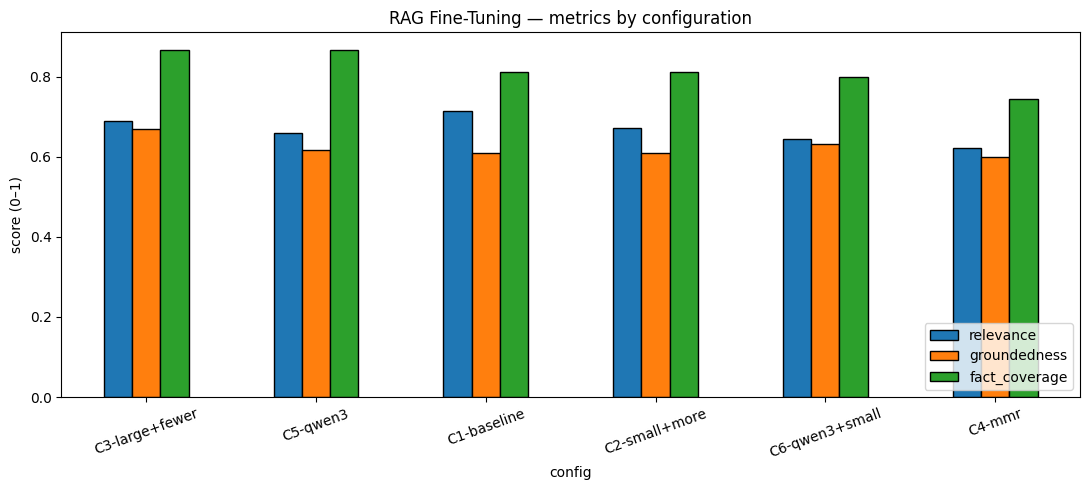

In [19]:
# --- Aggregate per configuration, rank, comment, and visualise ---
import matplotlib.pyplot as plt

agg = (tuning_df.groupby("config")[["relevance", "groundedness", "fact_coverage"]]
       .mean().round(3))
# Combined score weighted toward grounded, factual answers for HR policy use.
agg["combined"] = (0.30 * agg["relevance"]
                   + 0.40 * agg["groundedness"]
                   + 0.30 * agg["fact_coverage"]).round(3)
agg = agg.sort_values("combined", ascending=False)
print("Configuration leaderboard (sorted by combined score):")
display(agg)

# Produce run-specific comments for every tested configuration for transparent comparison.
tuning_observations = []
for config_id, row in agg.iterrows():
    metric_values = row[["relevance", "groundedness", "fact_coverage"]]
    strongest = metric_values.idxmax()
    weakest = metric_values.idxmin()
    cfg = next(c for c in CONFIGS if c["id"] == config_id)
    tuning_observations.append({
        "config": config_id,
        "retrieval_settings": (
            f"chunk={cfg['chunk_size']}/{cfg['chunk_overlap']}, k={cfg['k']}, "
            f"search={cfg['search_type']}, emb={cfg['emb_id'].split('/')[-1]}"
        ),
        "strongest_metric": f"{strongest}={row[strongest]:.3f}",
        "weakest_metric": f"{weakest}={row[weakest]:.3f}",
        "combined": row["combined"],
        "observation": (
            f"Strongest on {strongest}; weakest on {weakest}. "
            "Review individual answers and citations before treating the aggregate as decisive."
        ),
    })
print("\nRun-specific observations for all six configurations:")
display(pd.DataFrame(tuning_observations))

# Select the highest-scoring configuration as the tuned pipeline.
# With only three benchmark questions, close scores should be interpreted cautiously.
BEST_CONFIG_ID = agg.index[0]
BEST_CONFIG = next(c for c in CONFIGS if c["id"] == BEST_CONFIG_ID)
print(f"\n🏆 Best configuration: {BEST_CONFIG_ID} -> {BEST_CONFIG}")

ax = agg[["relevance", "groundedness", "fact_coverage"]].plot(
    kind="bar", figsize=(11, 5), rot=20, edgecolor="black")
ax.set_title("RAG Fine-Tuning — metrics by configuration")
ax.set_ylabel("score (0–1)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [20]:
# --- Build the tuned "production" pipeline from the best configuration ---
best_retriever = build_retriever(BEST_CONFIG)
best_llm = get_llm(BEST_CONFIG["temperature"])

best_answers = tuning_answers[BEST_CONFIG_ID]   # already generated above
show_answers(best_answers, f"5. TUNED RAG ANSWERS — {BEST_CONFIG_ID}")

best_rag_eval = evaluate_answers([strip_citation(a) for a in best_answers], f"5. Tuned RAG ({BEST_CONFIG_ID})")
print("\nTuned RAG scores:")
display(best_rag_eval)


5. TUNED RAG ANSWERS — C3-large+fewer

### Q1: Probation extension

If your probation is extended, the following effects on benefits remain unchanged:  - You are **not
eligible** for annual leave encashment, internal role transfers, or performance bonuses during the
entire probationary period—including any extension [Page 2, Section: Probationary Employment
Policy].  - Seniority accrual **does not begin** until after successful completion of probation
(i.e., upon passing the final probation review and being deemed permanently employed).  - There is
**no automatic continuation** of benefits such as health insurance or pension contributions during
the extension—these are typically tied to permanent employment status, which begins only after
successful probation completion.  Importantly, while the extension itself does not alter the core
benefit restrictions, the extension must meet specific criteria:   - It can only be granted once,
for up to 90 additional days.   - A written PIP must b

,method,question,relevance,groundedness,fact_coverage
0,5. Tuned RAG (C3-large+fewer),Q1: Probation extension,0.767,0.754,0.6
1,5. Tuned RAG (C3-large+fewer),Q2: Bereavement leave,0.673,0.635,1.0
2,5. Tuned RAG (C3-large+fewer),Q3: Harassment reporting,0.625,0.618,1.0


#### 🗒️ Observations — RAG Fine-Tuning

- **Every configuration indexes the full cleaned handbook**, answers all three questions, and is ranked by a combined score (**0.30·relevance + 0.40·groundedness + 0.30·fact_coverage**, weighted toward grounded/factual answers for HR compliance). The top-ranked config is selected programmatically as `BEST_CONFIG_ID`; no winner is hard-coded.
- **Interpret small differences cautiously.** With only three benchmark questions, close combined scores are best treated as an effective tie rather than evidence that one lever is universally superior. A representative query set is required before production selection.
- **What each retrieval lever tests:**
  - **`k`** is a recall/precision trade-off: fewer chunks can miss a clause; more chunks can add unrelated policy text and latency.
  - **chunk size / overlap** trades focused clauses against broader context; the leaderboard above shows the observed result rather than assuming one size must win.
  - **`search_type`** compares simple similarity with diversity-aware MMR.
  - **embedding model** compares lightweight MiniLM with the larger Qwen3 embedding model.
- **Decoding remains greedy (`temperature=0.0`)** for every configuration, so the experiment isolates retrieval settings and is reproducible.
- **Qualitative review remains mandatory.** A high aggregate score cannot excuse an unsupported approval rule, a missing condition, or a deadline borrowed from the wrong policy category.

**Takeaway:** The notebook deploys the top-ranked configuration for this prototype, while production should prefer a simple robust configuration only after re-tuning and human review on a larger representative query log.

---
## 6. Actionable Insights & Recommendations

We compare **all four approaches** — LLM-only, LLM + Prompt Engineering, default RAG, and the tuned RAG — on the same metrics, then summarise the business takeaways.

Method comparison (averages over the 3 questions):


,relevance,groundedness,fact_coverage
method,,,
1. LLM-only,0.765,0.489,0.244
2. LLM + prompt eng.,0.505,0.597,0.122
4. RAG,0.713,0.608,0.811
5. Tuned RAG (C3-large+fewer),0.688,0.669,0.867


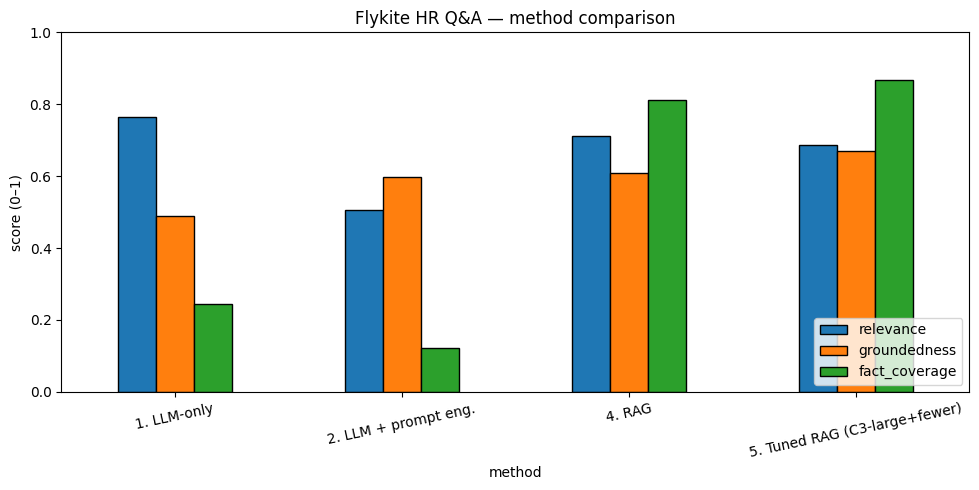

In [21]:
# --- Final comparison across all methods ---
final = pd.concat([baseline_eval, prompted_eval, rag_eval, best_rag_eval])
final_summary = (final.groupby("method")[["relevance", "groundedness", "fact_coverage"]]
                 .mean().round(3))
# Keep the logical method order
order = ["1. LLM-only", "2. LLM + prompt eng.", "4. RAG", f"5. Tuned RAG ({BEST_CONFIG_ID})"]
final_summary = final_summary.reindex([m for m in order if m in final_summary.index])
print("Method comparison (averages over the 3 questions):")
display(final_summary)

ax = final_summary.plot(kind="bar", figsize=(10, 5), rot=12, edgecolor="black")
ax.set_title("Flykite HR Q&A — method comparison")
ax.set_ylabel("score (0–1)")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.1 Comparison of Methods

| Method | Groundedness | Citations | Company-specific accuracy | Verdict |
|--------|--------------|-----------|---------------------------|---------|
| **LLM-only** | Low | ❌ | Guesses / hallucinates | Fluent but unreliable |
| **LLM + Prompt Eng.** | Limited | ❌ | Safer refusal, still lacks policy facts | Useful safety layer |
| **RAG (default)** | Higher | ✅ evidence-linked refs | Uses Flykite evidence; requires condition/deadline review | Trustworthy baseline with guardrails |
| **Tuned RAG** | Higher | ✅ evidence-linked refs | Evaluated across six retrieval configs | Prototype selection; validate before production |

The decisive jump is grounding. Prompt engineering improves *how* the model answers, while retrieval changes *what policy evidence it can access*. Fact coverage moves from 0.244 (LLM-only) and 0.122 (prompt-engineered) to 0.811 with default RAG and 0.867 after tuning, and only the RAG methods can cite handbook evidence.

Relevance behaves differently from the other two metrics. The prompt-engineered answers score lowest on relevance (0.505) because a large share of the response explains what cannot be confirmed, and tuned RAG (0.688) sits slightly below default RAG (0.713) even though it is better grounded. A single semantic score is therefore not a safe basis for choosing a method.

Among the RAG variants the ranking is close: C3 leads C5 by 0.029 combined score on three questions. Such margins are an effective tie, so simplicity, latency, and human-reviewed accuracy carry as much weight as the nominal winner.

### 6.2 Key Takeaways for the Business

- An evidence-backed assistant is deployable; a bare LLM is not. Without retrieval the model invents plausible entitlements, which is a compliance and legal risk in HR.
- Citations are what make the answers usable. Document, section, page, and the exact retrieved clause allow employees and auditors to verify a claim instead of trusting the model.
- Data hygiene is part of accuracy. Watermark and footer text is removed and verified before indexing so that retrieval scores reflect genuine policy content.
- Policy boundaries must be enforced in the prompt. Approval rules, reporting deadlines, and exceptions stay attached to their own policy category, and missing evidence is disclosed rather than substituted.
- Retrieval settings should be re-tuned on a real query log. Three questions demonstrate the workflow but cannot establish a universally best configuration.
- Expected impact: fewer repetitive HR tickets, faster round-the-clock self-service, and more consistent guidance — on the condition that incomplete or conflicting evidence is escalated to HR rather than answered.

---
## 7. System Behaviour Demonstration

The three benchmark questions remain unchanged for the quantitative comparison. The following demonstrations examine additional behaviours needed in an employee-facing assistant:

- ambiguity is identified before retrieval,
- supplied conversation history supports follow-up resolution,
- role, location, and department context is accepted without inventing unsupported policy variants, and
- every generated policy response includes document, section, page, and retrieved-clause evidence.

### 7.1 Demonstration Cases

The first case returns a clarification without calling the model. The second case uses one prior user question together with an employee profile to answer a follow-up from retrieved evidence. Because the handbook holds no structured role or location variants, the assistant answers from the general policy instead of inventing a cabin-crew or Delhi-specific rule.

In [22]:
# --- Objective-alignment wrapper: ambiguity, follow-ups, and employee profile ---
LEAVE_CATEGORIES = (
    "bereavement", "special leave", "annual leave", "casual leave", "sick leave",
    "jury duty", "emergency family care", "natural disaster",
)

def _needs_leave_clarification(question: str, history=None) -> bool:
    q = question.lower()
    has_leave_word = "leave" in q or "time off" in q
    has_category = any(category in q for category in LEAVE_CATEGORIES)
    return has_leave_word and not has_category and not history

def _employee_context(profile=None) -> str:
    if not profile:
        return "Not provided"
    allowed = ("role", "location", "department")
    values = [f"{key.title()}: {profile[key]}" for key in allowed if profile.get(key)]
    return "; ".join(values) if values else "Not provided"

def ask(question: str, employee_profile=None, history=None) -> str:
    """Answer with the tuned RAG pipeline.

    `history` is an optional list of `(user_question, assistant_answer)` tuples. Only
    prior user questions are added to retrieval; prior generated answers are never
    treated as policy evidence. `employee_profile` may contain role/location/department.
    """
    if _needs_leave_clarification(question, history=history):
        return (
            "Clarification needed: Which leave category do you mean (for example, "
            "bereavement/special leave, annual leave, sick leave, or emergency family care), "
            "and is the absence planned or sudden?"
        )

    prior_questions = [turn[0] for turn in (history or []) if turn and turn[0]]
    retrieval_query = " ".join(prior_questions[-2:] + [question])
    if prior_questions:
        generation_question = (
            "Previous employee question(s): " + " | ".join(prior_questions[-2:]) +
            "\nCurrent follow-up question: " + question
        )
    else:
        generation_question = question

    return rag_answer(
        generation_question,
        the_retriever=best_retriever,
        chat_model=best_llm,
        retrieval_query=retrieval_query,
        employee_context=_employee_context(employee_profile),
    )

print("AMBIGUOUS QUERY DEMONSTRATION")
ambiguous_q = "Can I take leave next week?"
print(f"Q: {ambiguous_q}\n{ask(ambiguous_q)}")

print("\n" + "=" * 90 + "\nFOLLOW-UP + EMPLOYEE PROFILE DEMONSTRATION")
followup_history = [("I need bereavement leave because my grandfather passed away.", "")]
followup_q = "What documents do I need, and when must I submit them?"
profile = {"role": "Cabin crew", "location": "Delhi", "department": "Flight Operations"}
print(f"Profile: {profile}\nQ: {followup_q}\n")
print(ask(followup_q, employee_profile=profile, history=followup_history))

AMBIGUOUS QUERY DEMONSTRATION
Q: Can I take leave next week?
Clarification needed: Which leave category do you mean (for example, bereavement/special leave, annual leave, sick leave, or emergency family care), and is the absence planned or sudden?

FOLLOW-UP + EMPLOYEE PROFILE DEMONSTRATION
Profile: {'role': 'Cabin crew', 'location': 'Delhi', 'department': 'Flight Operations'}
Q: What documents do I need, and when must I submit them?

For bereavement leave due to your grandfather's passing, you are entitled to up to 5 consecutive working days under the Special Leave Policy (Section 1, Page 6), covering immediate family members including grandparents [Page 6].

### Documents Required:
- **Obituary or funeral notice** (as proof of death and family relationship) [Page 7, Section: Special Leave Policy – Documentation Requirements]

> Note: While the policy mentions death certificates, funeral notices, or obituaries for bereavement, the specific requirement for a death certificate is not ex

---
## 8. Conclusion

The notebook traces one problem through four solutions: a no-retrieval LLM baseline, safer prompt engineering, evidence-linked RAG over the prepared handbook, and a six-configuration retrieval sweep.

The pattern across the results is consistent. Prompt engineering changes how the model answers; retrieval changes what it knows. Default RAG lifts policy fact coverage to 0.811, and the `C3-large+fewer` configuration reaches 0.867 fact coverage, 0.669 groundedness, and a 0.734 combined score, while keeping every policy claim tied to a page, section, and retrieved clause.

That is a controlled-pilot result rather than production proof. Three questions cannot separate configurations reliably, embedding similarity and keyword coverage are diagnostic proxies rather than claim-level verification, and the handbook contains no structured role, location, or department variants for metadata filtering. Conversation history is handled within a request only, and a larger model would not remove any of these constraints.

For Flykite, the practical reading is that the assistant is ready to be piloted for policy discovery and explanation, with citations shown to the employee and with ambiguous questions, missing or conflicting evidence, and any request for a binding decision routed to HR.